# Validate grid registration fix

Verify that the on-disk V-roll + F-point coordinate fix produces correct
trajectories with smooth nest transitions.

In [1]:
import os
import shutil
import warnings
from datetime import timedelta
from pathlib import Path

import numpy as np
import xarray as xr

warnings.filterwarnings("ignore", category=xr.SerializationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

from parcels import FieldSet, JITParticle, ParticleSet, NestedField

import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 300
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection

# Load 2D fields (already have F-point coords and NEMO V convention)

In [2]:
surf_coarse = Path("/tmp/test_003_output/c_file_coarse_2020010100_000_006_surface.nc")
surf_fine = Path("/tmp/test_003_output/c_file_fine_2020010100_000_006_surface.nc")

ds_c = xr.open_dataset(surf_coarse)
ds_f = xr.open_dataset(surf_fine)
print(f"Coarse: {ds_c.sizes['lat']}x{ds_c.sizes['lon']}, lat=[{ds_c.lat.values[0]:.4f}..{ds_c.lat.values[-1]:.4f}]")
print(f"Fine:   {ds_f.sizes['lat']}x{ds_f.sizes['lon']}, lat=[{ds_f.lat.values[0]:.4f}..{ds_f.lat.values[-1]:.4f}]")

fine_n = float(ds_f.lat.values[0])
fine_s = float(ds_f.lat.values[-1])
fine_w = float(ds_f.lon.values[0])
fine_e = float(ds_f.lon.values[-1])
print(f"Fine boundaries: N={fine_n:.4f} S={fine_s:.4f} W={fine_w:.4f} E={fine_e:.4f}")

Coarse: 347x414, lat=[65.9000..48.6000]
Fine:   385x629, lat=[56.4416..53.2416]
Fine boundaries: N=56.4416 S=53.2416 W=6.1806 E=14.9027


# Build nested FieldSet

In [3]:
dim_dict = dict(lon="lon", lat="lat", time="time")

def make_fs(data_file):
    fnames = {"U": [str(data_file)], "V": [str(data_file)]}
    return FieldSet.from_netcdf(
        filenames=fnames,
        variables={"U": "uvel", "V": "vvel"},
        dimensions={"U": dim_dict, "V": dim_dict},
        interp_method={"U": "cgrid_velocity", "V": "cgrid_velocity"},
        allow_time_extrapolation=True,
        gridindexingtype="nemo",
    )

fs_fine = make_fs(surf_fine)
fs_coarse = make_fs(surf_coarse)

U_nested = NestedField("U", [fs_fine.U, fs_coarse.U])
V_nested = NestedField("V", [fs_fine.V, fs_coarse.V])
fieldset = FieldSet(U_nested, V_nested)
print("Nested fieldset ready")

Nested fieldset ready


# Seed particles

In [4]:
rng = np.random.default_rng(42)

# Group 1: Pomeranian Bay (bulk flow test)
n1 = 500
lon1 = rng.uniform(17.0, 19.0, n1)
lat1 = rng.uniform(54.5, 55.4, n1)

# Group 2: fine grid N boundary (nest transition)
n2 = 1000
lon2 = rng.uniform(8.0, 13.0, n2)
lat2 = rng.uniform(fine_n - 0.12, fine_n + 0.12, n2)

# Group 3: fine grid W boundary (nest transition)
# Seed near 53.6N where there's mixed land/water at the fine W edge
n3 = 1000
lat3 = rng.uniform(53.3, 53.9, n3)
lon3 = rng.uniform(fine_w - 0.12, fine_w + 0.12, n3)

# Group 4: fine grid E boundary (nest transition)
n4 = 1000
lat4 = rng.uniform(54.0, 56.0, n4)
lon4 = rng.uniform(fine_e - 0.12, fine_e + 0.12, n4)

release_lons = np.concatenate([lon1, lon2, lon3, lon4])
release_lats = np.concatenate([lat1, lat2, lat3, lat4])
group_ids = np.concatenate([np.zeros(n1), np.ones(n2), 2 * np.ones(n3), 3 * np.ones(n4)])

print(f"Total: {len(release_lons)} particles")
print(f"Fine N: {fine_n:.4f}, W: {fine_w:.4f}, E: {fine_e:.4f}")

Total: 3500 particles
Fine N: 56.4416, W: 6.1806, E: 14.9027


# Kernels and execution

In [5]:
def AdvectionRK4_2D(particle, fieldset, time):
    dt = particle.dt
    lat0 = particle.lat
    lon0 = particle.lon
    time0 = time
    u1, v1 = fieldset.UV[time0, 0, lat0, lon0]
    lat1 = lat0 + v1 * 0.5 * dt
    lon1 = lon0 + u1 * 0.5 * dt
    u2, v2 = fieldset.UV[time0 + 0.5 * dt, 0, lat1, lon1]
    lat2 = lat0 + v2 * 0.5 * dt
    lon2 = lon0 + u2 * 0.5 * dt
    u3, v3 = fieldset.UV[time0 + 0.5 * dt, 0, lat2, lon2]
    lat3 = lat0 + v3 * dt
    lon3 = lon0 + u3 * dt
    u4, v4 = fieldset.UV[time0 + dt, 0, lat3, lon3]
    particle_dlon += (u1 + 2 * u2 + 2 * u3 + u4) / 6 * dt
    particle_dlat += (v1 + 2 * v2 + 2 * v3 + v4) / 6 * dt


def delete_oob(particle, fieldset, time):
    if particle.state == 41:
        particle.delete()


pset = ParticleSet(
    fieldset=fieldset,
    pclass=JITParticle,
    lon=release_lons,
    lat=release_lats,
    time=0.0,
)

zarr_path = "/tmp/validate_grid_fix.zarr"
if os.path.exists(zarr_path):
    shutil.rmtree(zarr_path)

output = pset.ParticleFile(name=zarr_path, outputdt=timedelta(minutes=15))

run_days = 30
print(f"Running {len(pset)} particles, {run_days}d, dt=5min...")
pset.execute(
    [AdvectionRK4_2D, delete_oob],
    dt=timedelta(minutes=5),
    endtime=run_days * 24 * 3600.0,
    output_file=output,
    verbose_progress=False,
)

ds_traj = xr.open_zarr(zarr_path)
print(f"Trajectories: {dict(ds_traj.sizes)}")

Running 3500 particles, 30d, dt=5min...


INFO: Output files are stored in /tmp/validate_grid_fix.zarr.


Trajectories: {'trajectory': 3500, 'obs': 2880}


# Build land masks from both coarse and fine original c_files

In [6]:
def build_land_mask(path):
    ds = xr.open_dataset(path)
    U = ds.uvel.sel(layer_number=1).isel(time=0).values
    V = ds.vvel.sel(layer_number=1).isel(time=0).values
    U_ok = ~np.isnan(U) & (U != 0.0)
    V_ok = ~np.isnan(V) & (V != 0.0)
    nj, ni = U.shape
    has_flux = np.zeros((nj, ni), dtype=bool)
    has_flux |= U_ok
    has_flux[:, 1:] |= U_ok[:, :-1]
    has_flux |= V_ok
    has_flux[1:, :] |= V_ok[:-1, :]
    lon = ds.lon.values
    lat = ds.lat.values
    dl = lon[1] - lon[0]
    da = abs(lat[1] - lat[0])
    return ~has_flux, lon, lat, dl, da

land_c, lon_c, lat_c, dlon_c, dlat_c = build_land_mask(
    "../data/bsh_hbmnoku_demo/c_file_coarse_2020/c_file_coarse_2020010100_000_006.nc")
land_f, lon_f, lat_f, dlon_f, dlat_f = build_land_mask(
    "../data/bsh_hbmnoku_demo/c_file_fine_2020/c_file_fine_2020010100_000_006.nc")

# The coarse grid has NaN in the rectangular fine-grid footprint (BSH blanks
# it out). Don't count those as land — they're ocean covered by the fine grid.
# Use the Parcels fine grid F-point boundaries (from the output file, after crop).
in_fine = (
    (lon_c[None, :] >= fine_w) & (lon_c[None, :] <= fine_e) &
    (lat_c[:, None] >= fine_s) & (lat_c[:, None] <= fine_n)
)
land_c[in_fine] = False

# Clip fine land to Parcels cell centers only (not boundary-only T-points).
# F-point coords are NE corners. Cell (yi,xi) = T-cell (yi+1, xi+1), so
# T-cell 0 in each dim is boundary data, not a cell center. Excluding
# T-points outside [fine_w, fine_e] x [fine_s, fine_n] drops exactly
# those boundary-only points. Their rectangles then start at the red line.
fine_out = (
    (lat_f[:, None] < fine_s) | (lat_f[:, None] > fine_n) |
    (lon_f[None, :] < fine_w) | (lon_f[None, :] > fine_e)
)
land_f[fine_out] = False

print(f"Coarse land (excl fine footprint): {land_c.sum()}/{land_c.size}")
print(f"Fine land (clipped to Parcels grid): {land_f.sum()}/{land_f.size}")

Coarse land (excl fine footprint): 103141/143658
Fine land (clipped to Parcels grid): 120710/243810


# Plot: Pomeranian Bay

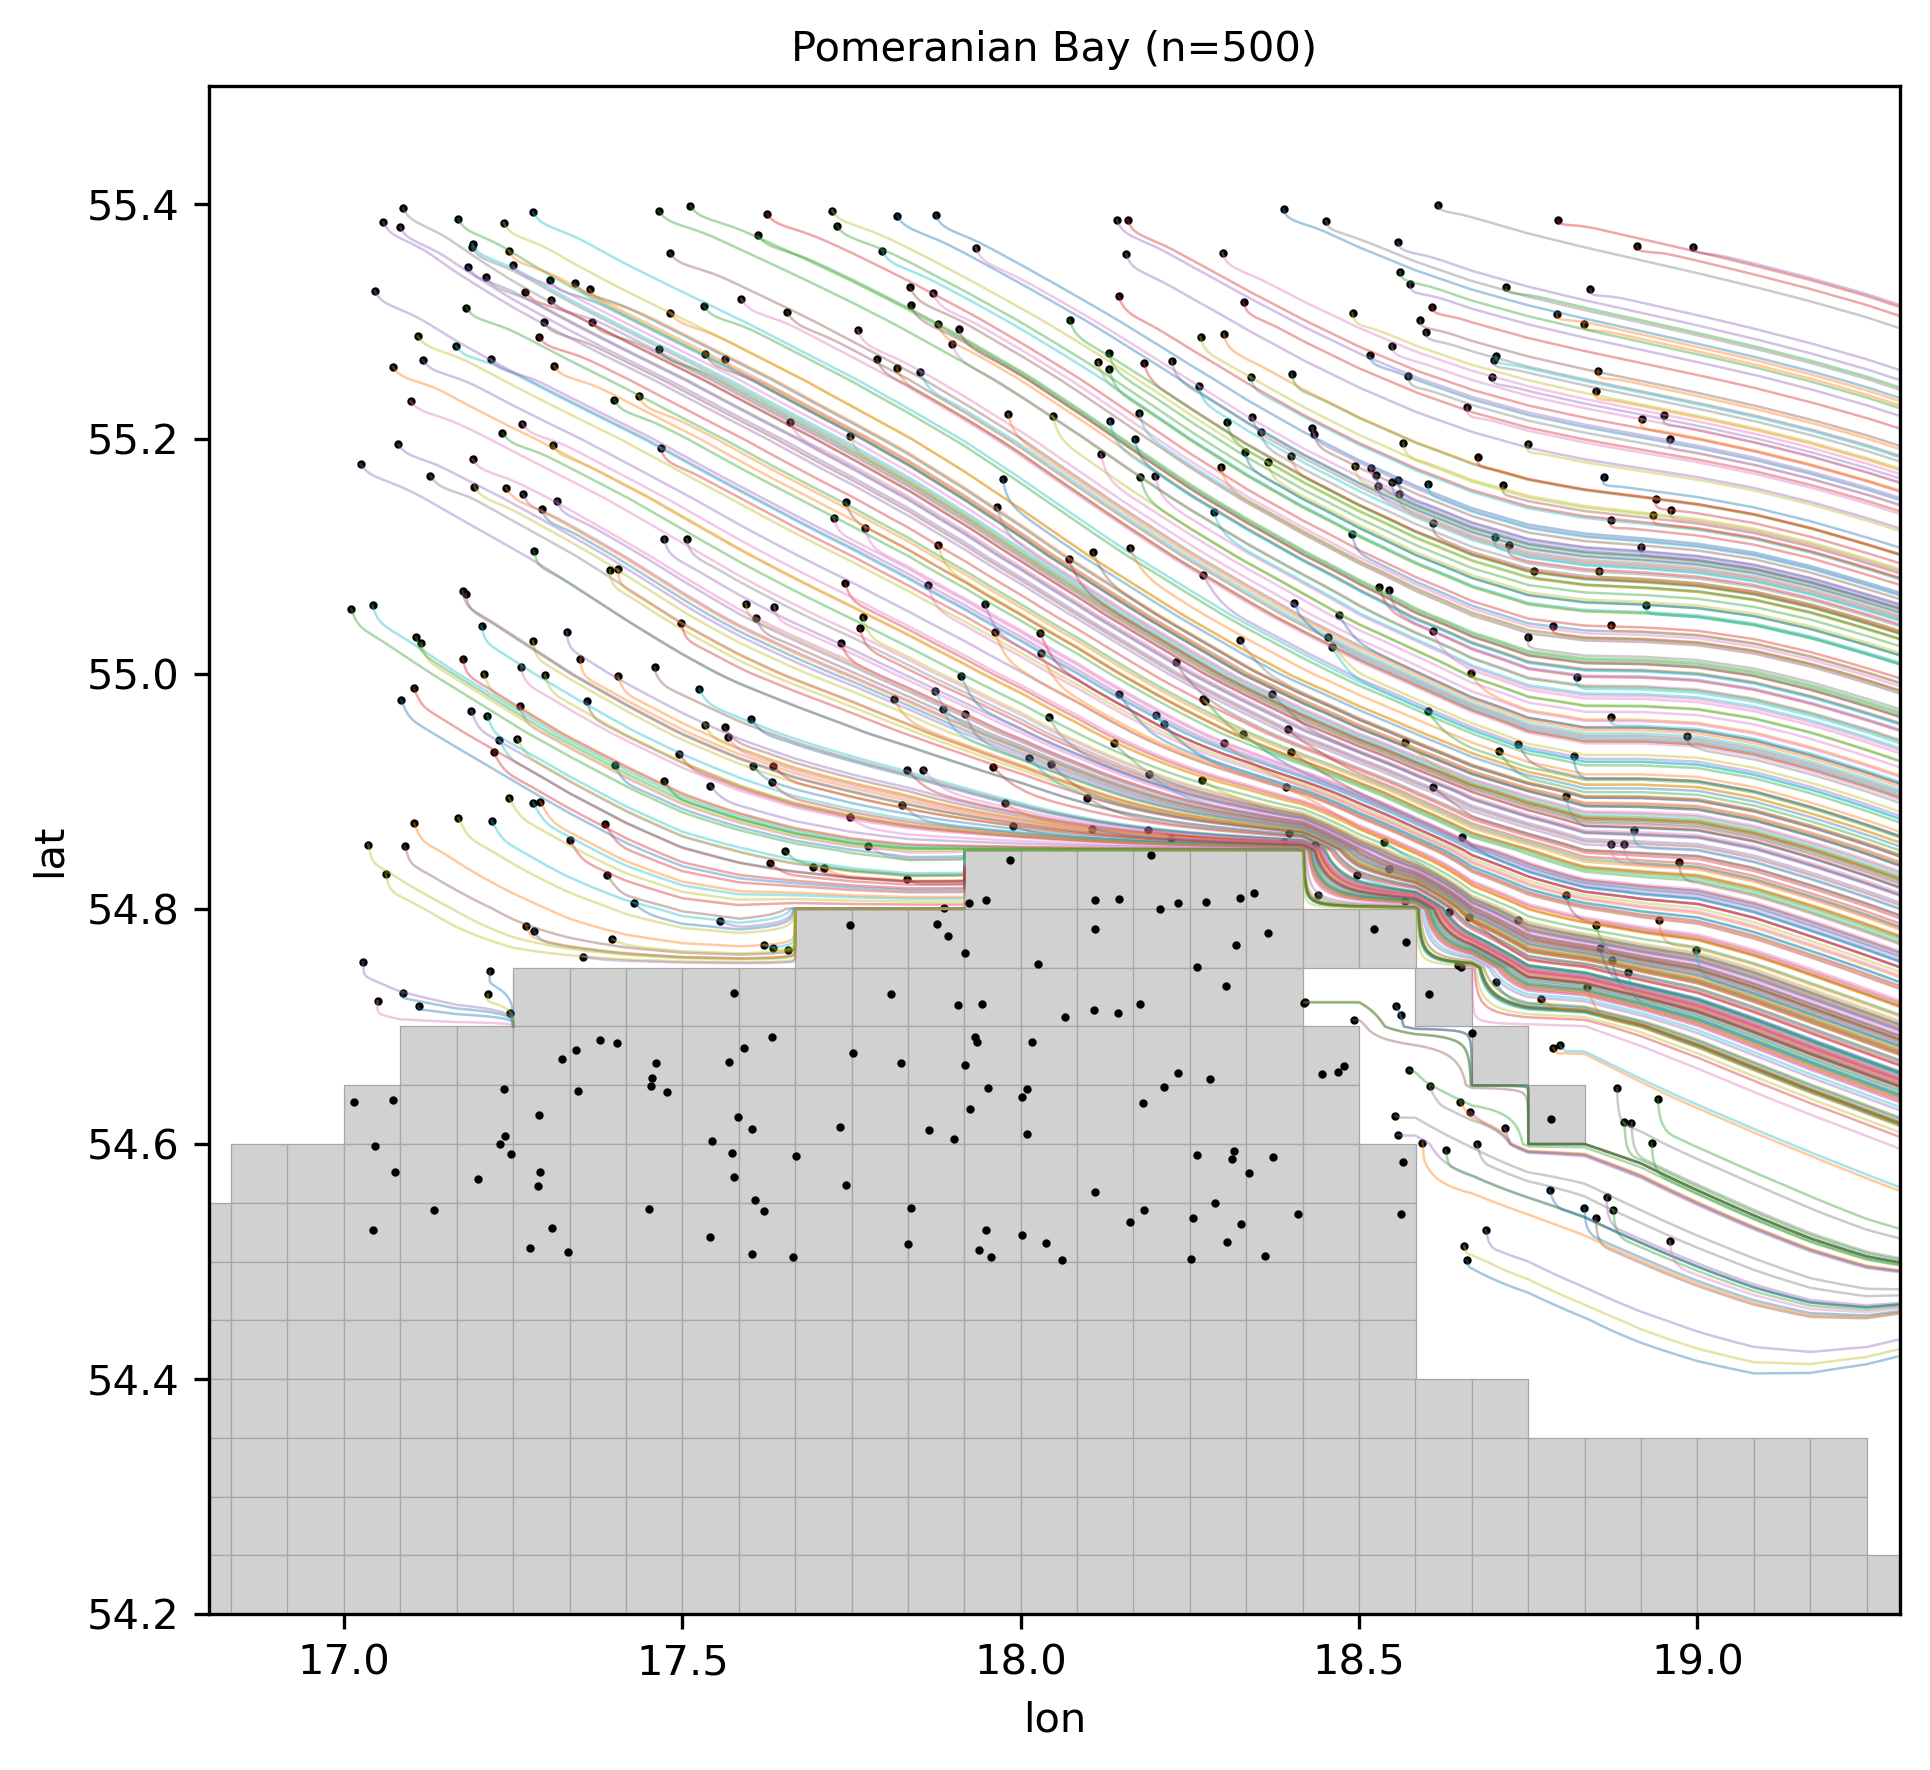

In [7]:
traj_lon = ds_traj.lon.values
traj_lat = ds_traj.lat.values

def land_patches(mask, lon, lat, dl, da, lon_range, lat_range):
    patches = []
    for j in range(len(lat)):
        for i in range(len(lon)):
            if mask[j, i]:
                cl, ct = lon[i], lat[j]
                if (lon_range[0] - dl <= cl <= lon_range[1] + dl and
                    lat_range[0] - da <= ct <= lat_range[1] + da):
                    patches.append(Rectangle(
                        (cl - dl / 2, ct - da / 2), dl, da))
    return patches

def plot_region(ax, title, lon_range, lat_range, group_mask,
                boundary_lines=None, show_fine_land=False):
    # Coarse land
    pc = land_patches(land_c, lon_c, lat_c, dlon_c, dlat_c, lon_range, lat_range)
    if pc:
        ax.add_collection(PatchCollection(
            pc, facecolor="0.82", edgecolor="0.65", linewidth=0.3))
    # Fine land (smaller cells, slightly darker)
    if show_fine_land:
        pf = land_patches(land_f, lon_f, lat_f, dlon_f, dlat_f, lon_range, lat_range)
        if pf:
            ax.add_collection(PatchCollection(
                pf, facecolor="0.72", edgecolor="0.55", linewidth=0.15))

    idx = np.where(group_mask)[0]
    init_lon = traj_lon[idx, 0]
    init_lat = traj_lat[idx, 0]
    valid = ~np.isnan(init_lon)
    ax.plot(init_lon[valid], init_lat[valid], ".", color="black", markersize=2)

    for i in idx:
        lt = traj_lon[i]
        la = traj_lat[i]
        v = ~np.isnan(lt)
        if v.sum() > 1:
            ax.plot(lt[v], la[v], linewidth=0.6, alpha=0.4)

    if boundary_lines:
        for orient, val in boundary_lines:
            if orient == "h":
                ax.axhline(val, color="red", linewidth=1, linestyle="--", label="fine boundary")
            else:
                ax.axvline(val, color="red", linewidth=1, linestyle="--", label="fine boundary")

    ax.set_xlim(lon_range)
    ax.set_ylim(lat_range)
    ax.set_aspect(1 / np.cos(np.radians(np.mean(lat_range))))
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")

fig, ax = plt.subplots(figsize=(8, 6))
plot_region(ax, f"Pomeranian Bay (n={n1})",
            [16.8, 19.3], [54.2, 55.5], group_ids == 0, show_fine_land=True)
fig.tight_layout()
plt.show()

# Plot: Fine N boundary

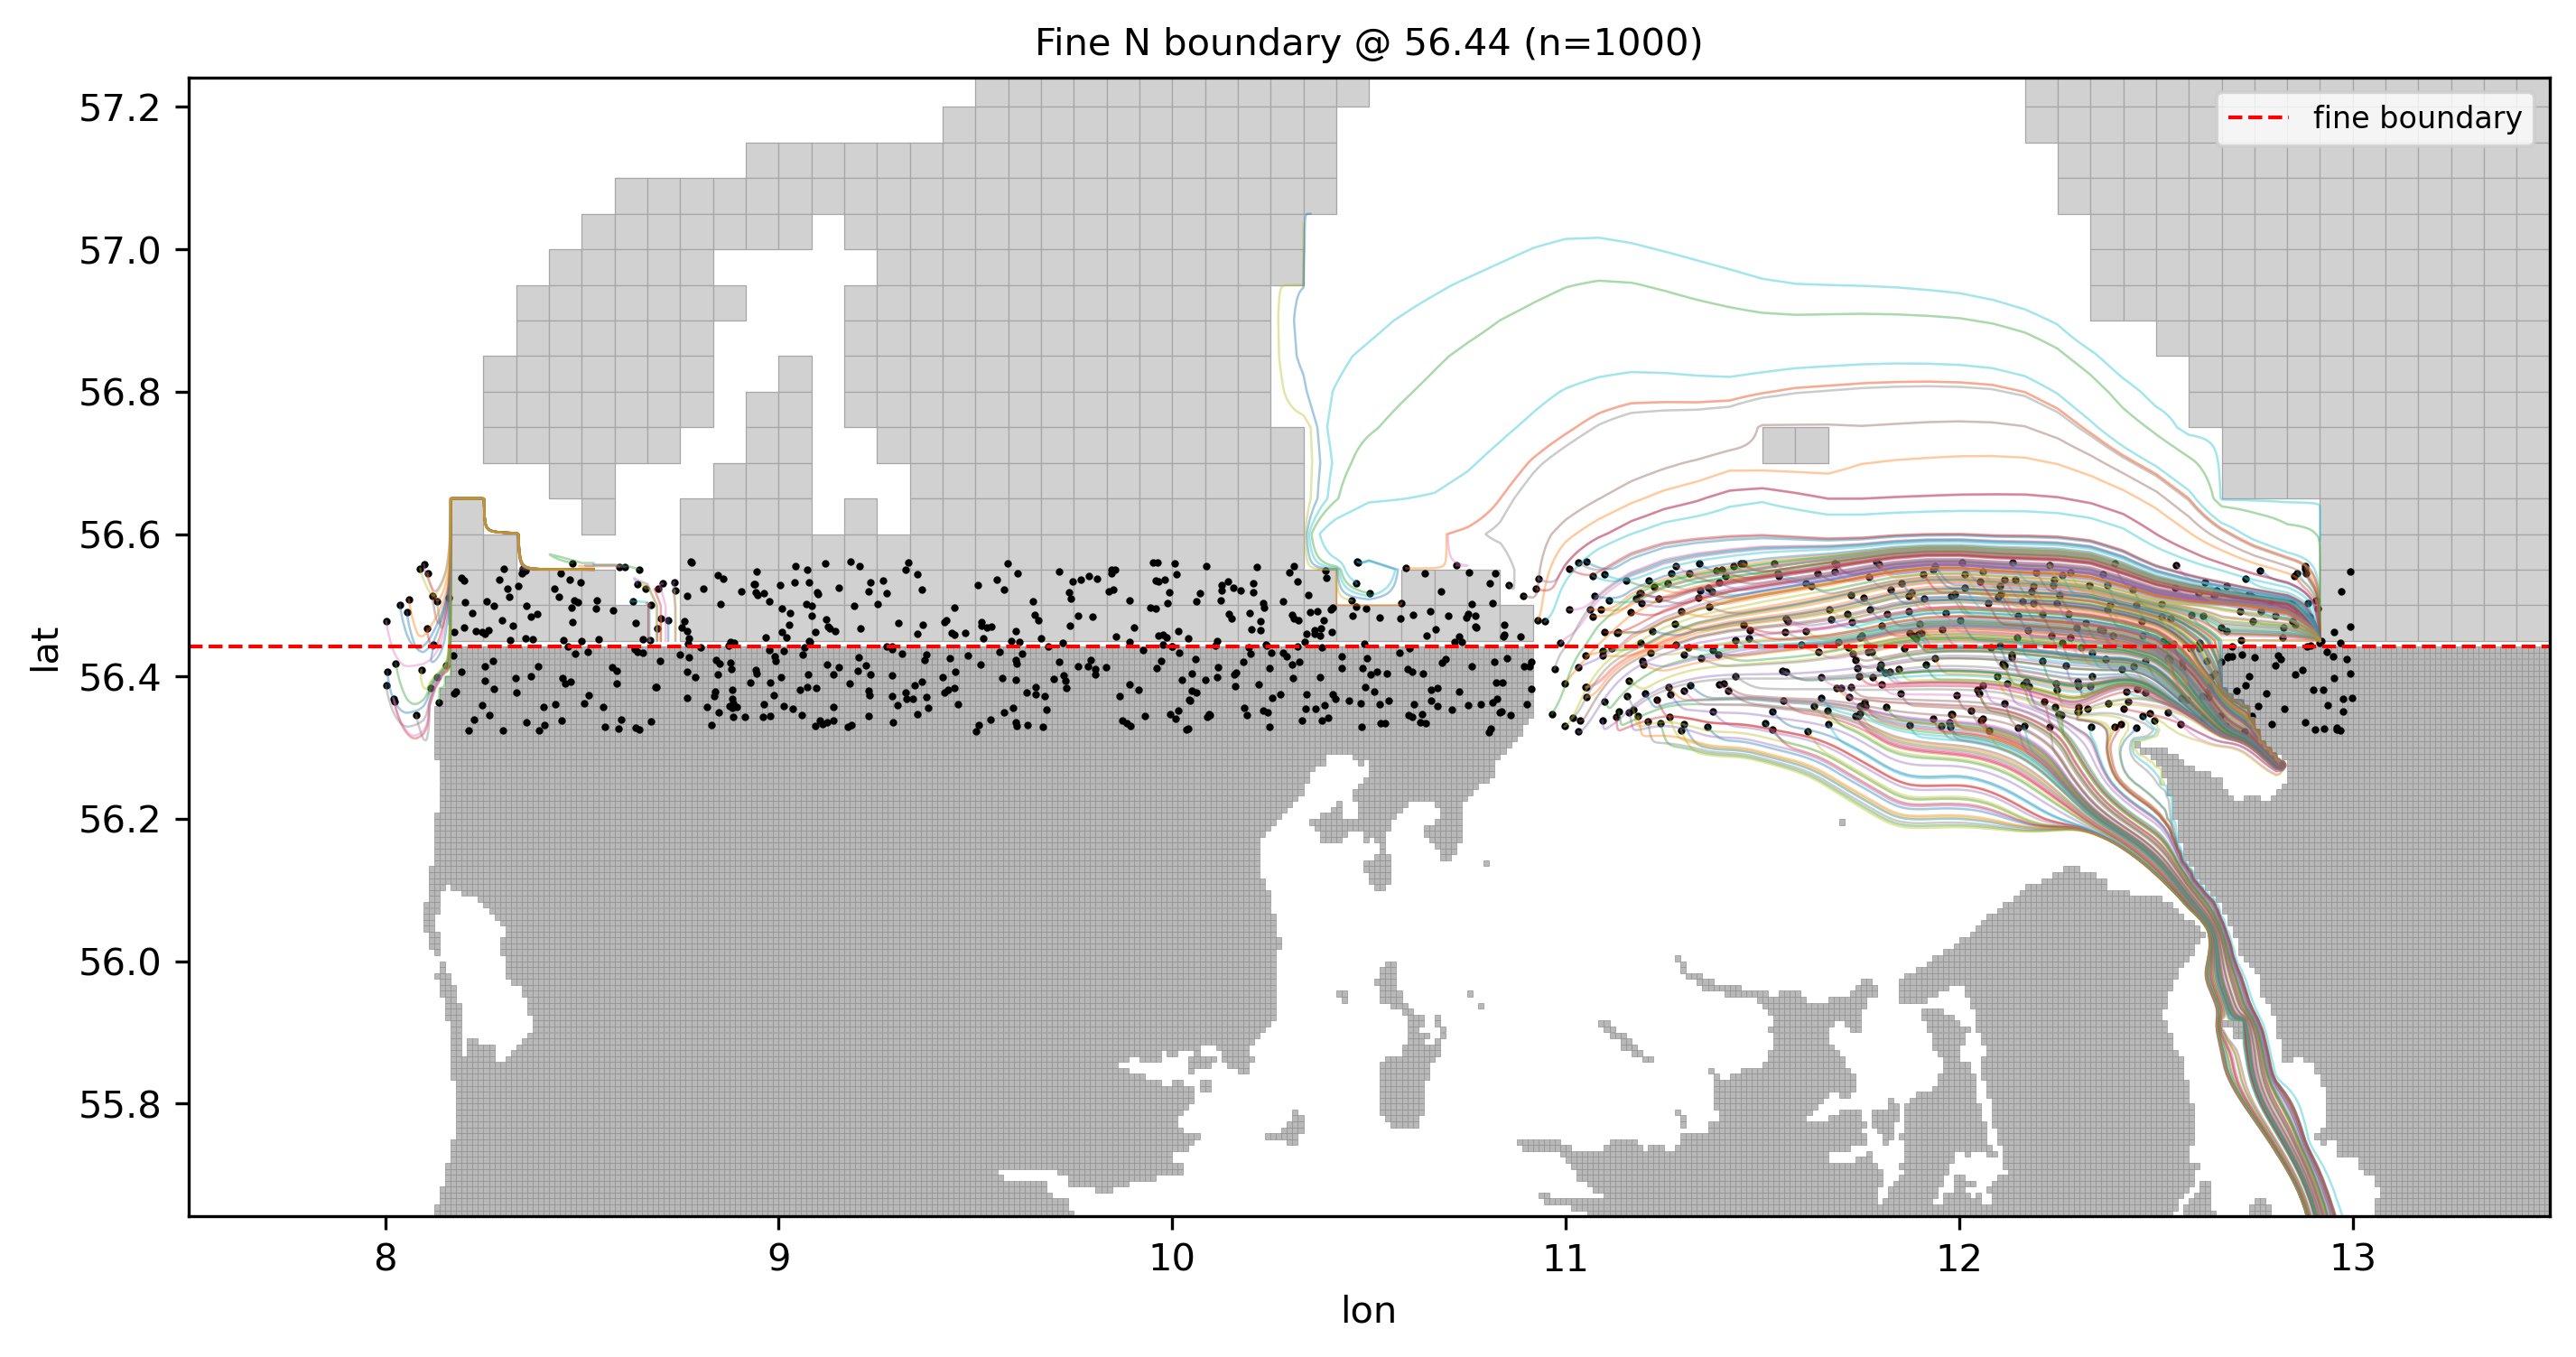

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_region(ax, f"Fine N boundary @ {fine_n:.2f} (n={n2})",
            [7.5, 13.5], [fine_n - 0.8, fine_n + 0.8], group_ids == 1,
            boundary_lines=[("h", fine_n)], show_fine_land=True)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

# Plot: Fine W boundary

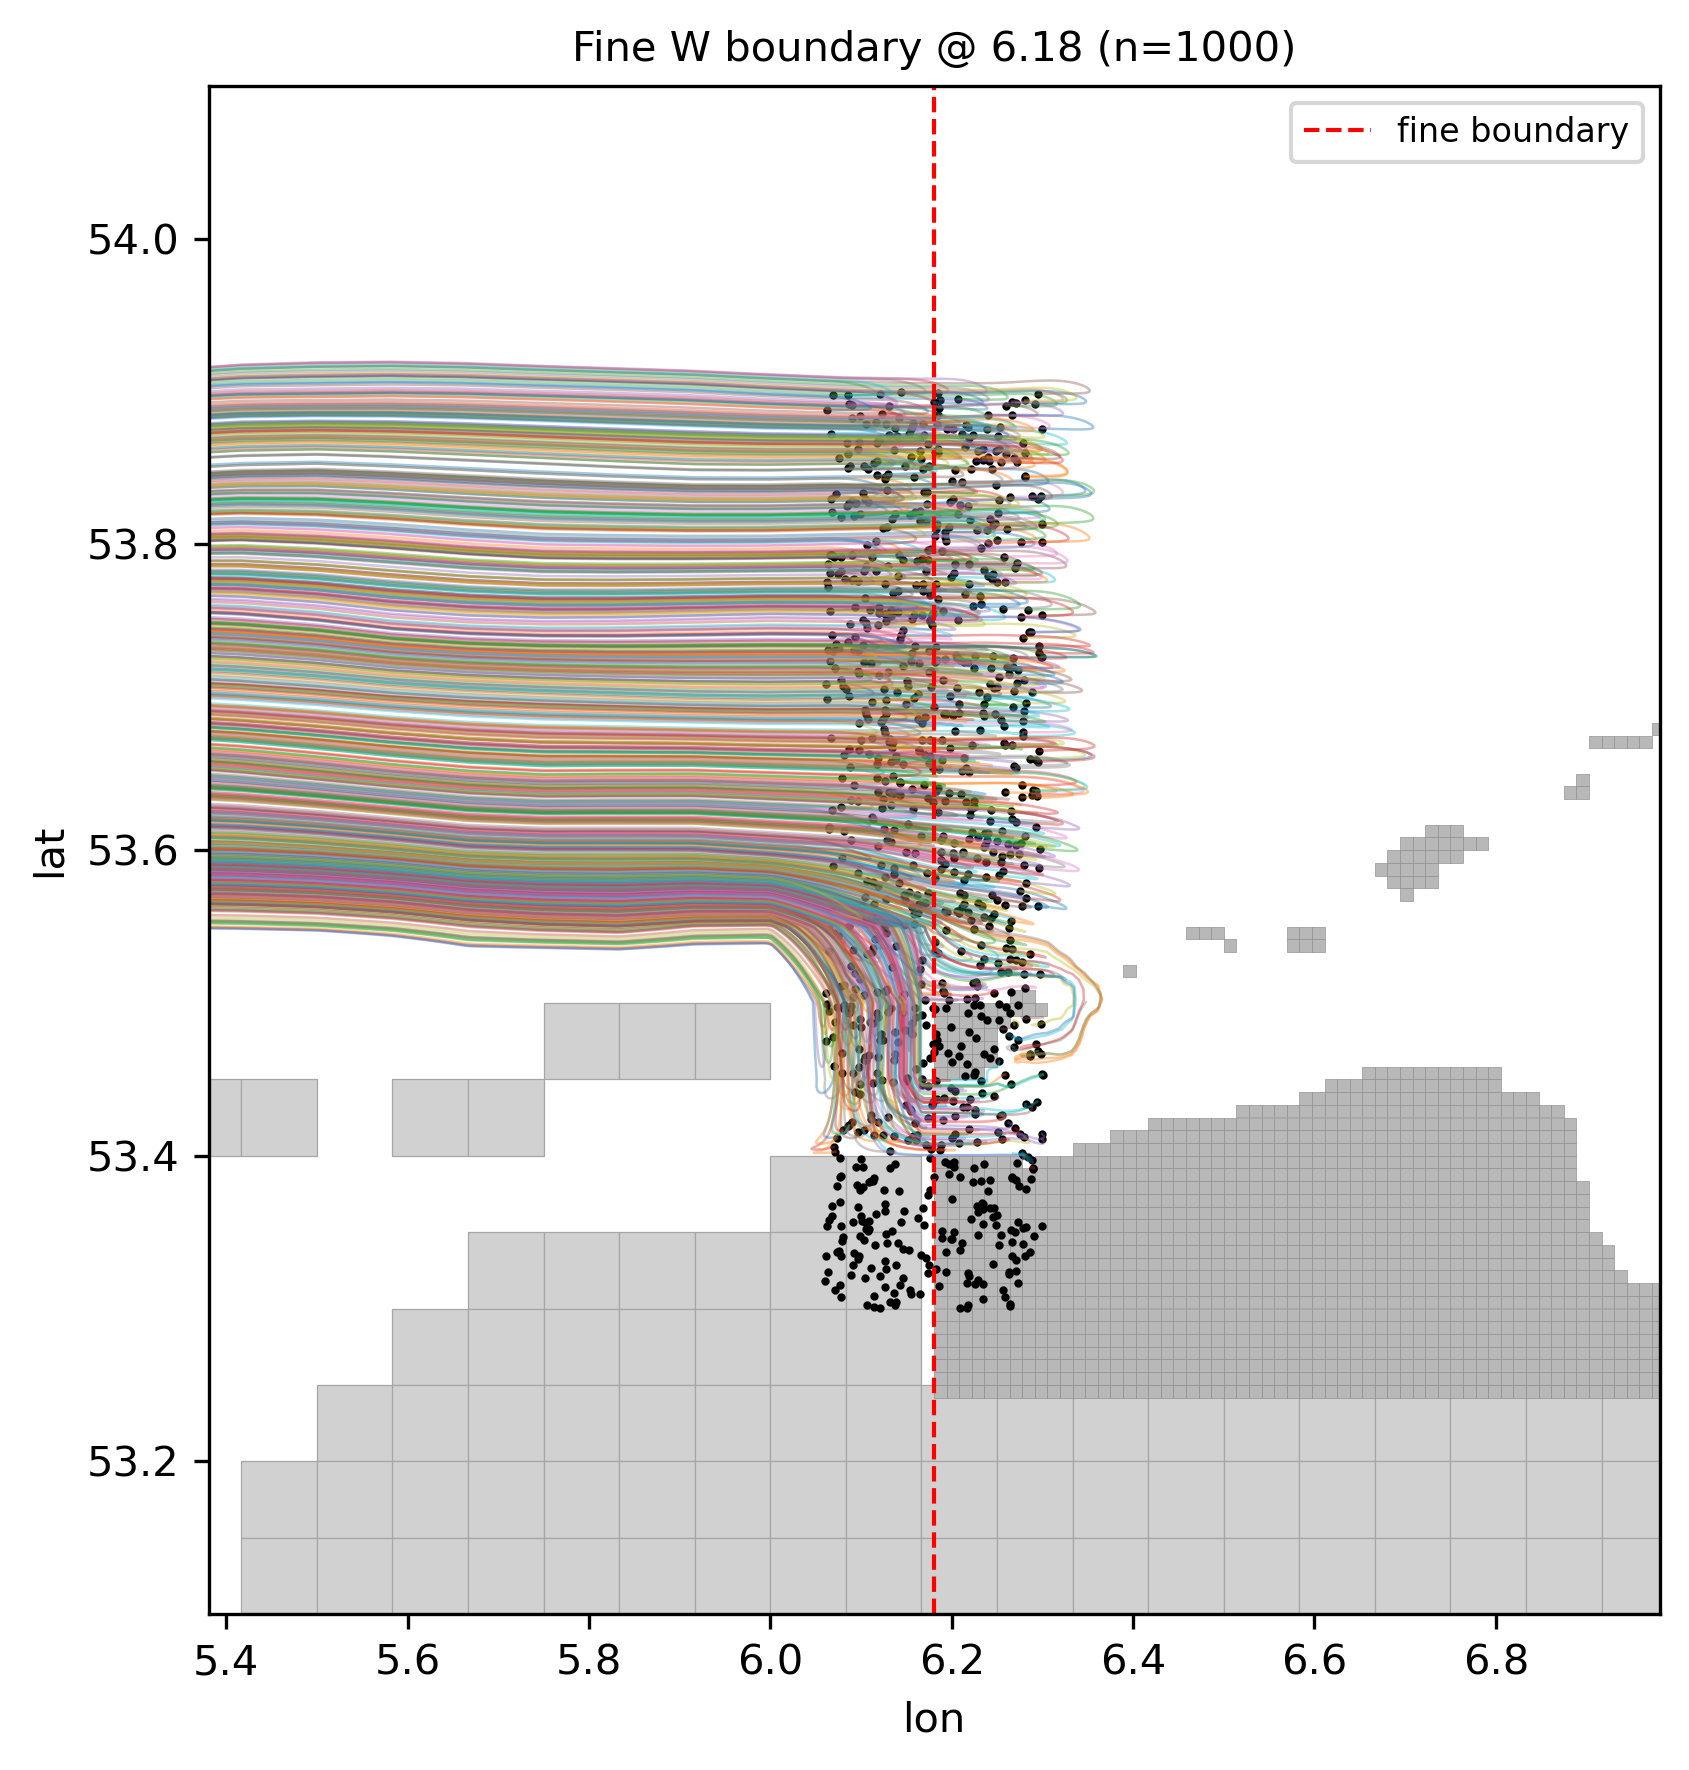

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
plot_region(ax, f"Fine W boundary @ {fine_w:.2f} (n={n3})",
            [fine_w - 0.8, fine_w + 0.8], [53.1, 54.1], group_ids == 2,
            boundary_lines=[("v", fine_w)], show_fine_land=True)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

# Plot: Fine E boundary

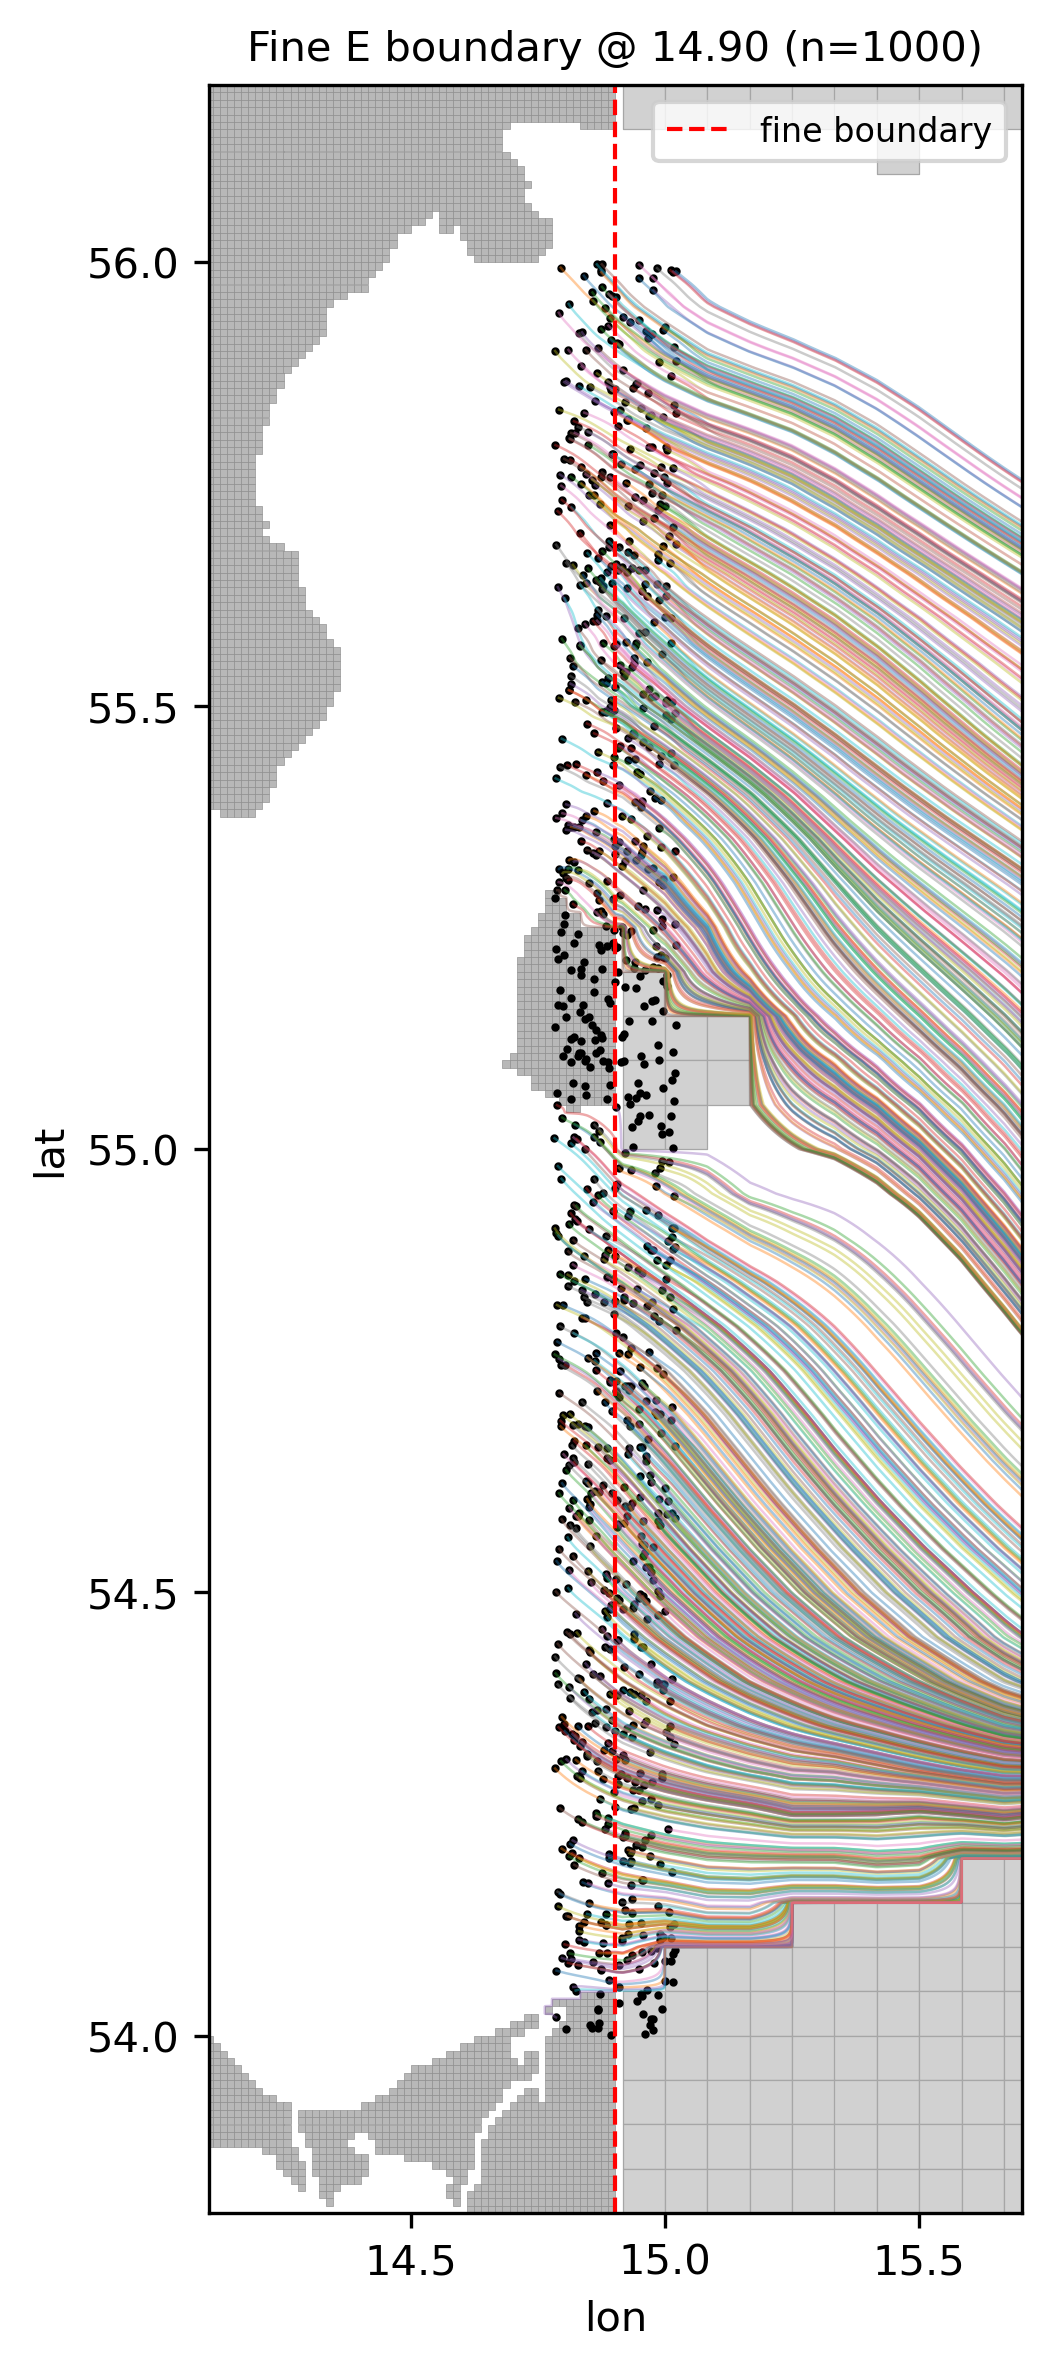

In [10]:
fig, ax = plt.subplots(figsize=(5, 8))
plot_region(ax, f"Fine E boundary @ {fine_e:.2f} (n={n4})",
            [fine_e - 0.8, fine_e + 0.8], [53.8, 56.2], group_ids == 3,
            boundary_lines=[("v", fine_e)], show_fine_land=True)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()